# Dataset Analysis

In [3]:
import config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


In [4]:
df_features = pd.read_csv(config.ALL_FEATURES_FILE_PATH)

In [5]:
df_kurtosis = df_features.filter(like='Kurtosis')
df_kurtosis

,Kurtosis,wavelet_Kurtosis,logarithm_Kurtosis,square_Kurtosis,squareroot_Kurtosis,exponential_Kurtosis,gradient_Kurtosis,lbp2D_Kurtosis
0,2.458492,2.641709,3.405517,2.089587,2.851386,2.442877,3.393915,3.779106
1,2.096824,2.126570,2.762081,1.913995,2.358704,2.070303,3.930567,2.602323
2,2.680965,2.454307,2.801337,2.580611,2.739111,2.452058,3.962098,2.758136
3,2.824784,2.399478,2.592860,3.201056,2.691551,4.942827,4.027631,2.305384
4,2.458615,2.903314,2.565648,2.381003,2.508846,2.347781,2.175480,2.306927
...,...,...,...,...,...,...,...,...
377,2.480920,2.512057,2.635683,2.383814,2.553100,2.377902,1.842921,1.596431
378,4.144502,4.506565,5.093382,3.482475,4.580525,2.638080,6.537047,3.016792
379,2.177497,2.737697,2.442417,1.987607,2.300233,1.771718,5.201709,3.735076
380,2.572334,2.490835,2.894376,2.376333,2.718479,2.314721,2.624650,1.653098


In [6]:
df_features[df_features.eq(df_features.iloc[:, 0], axis=0).all(axis=1)]

,group_name,m_id,day_of_study,10Percentile,90Percentile,Energy,Entropy,InterquartileRange,Kurtosis,Maximum,...,lbp2D_DependenceNonUniformityNormalized,lbp2D_DependenceVariance,lbp2D_HighGrayLevelEmphasis,lbp2D_LargeDependenceEmphasis,lbp2D_LargeDependenceHighGrayLevelEmphasis,lbp2D_LargeDependenceLowGrayLevelEmphasis,lbp2D_LowGrayLevelEmphasis,lbp2D_SmallDependenceEmphasis,lbp2D_SmallDependenceHighGrayLevelEmphasis,lbp2D_SmallDependenceLowGrayLevelEmphasis


In [7]:
# Iterar sobre cada fila del DataFrame
for index, row in df_features.iterrows():
    # Crear un diccionario que cuenta cuántas veces aparece cada valor en la fila
    value_counts = row.value_counts()

    # Iterar sobre cada valor que aparece más de una vez
    for value, count in value_counts.items():
        if count > 1:  # Solo si el valor aparece más de una vez
            # Encontrar las columnas que tienen este valor
            columns_with_same_value = row[row == value].index.tolist()
            print(f"Fila {index+1}: {', '.join(columns_with_same_value)} tienen el mismo valor: {value}")



Fila 1: DifferenceAverage, InverseVariance, LongRunEmphasis, RunLengthNonUniformityNormalized, RunPercentage, ShortRunEmphasis, LargeAreaEmphasis, SizeZoneNonUniformityNormalized, SmallAreaEmphasis, ZonePercentage, DependenceNonUniformityNormalized, LargeDependenceEmphasis, SmallDependenceEmphasis, wavelet_DifferenceAverage, wavelet_SumSquares, square_DifferenceAverage, square_InverseVariance, square_LongRunEmphasis, square_RunLengthNonUniformityNormalized, square_RunPercentage, square_ShortRunEmphasis, square_LargeAreaEmphasis, square_SizeZoneNonUniformityNormalized, square_SmallAreaEmphasis, square_ZonePercentage, square_DependenceNonUniformityNormalized, square_LargeDependenceEmphasis, square_SmallDependenceEmphasis, lbp2D_Median, lbp2D_Uniformity, lbp2D_Autocorrelation, lbp2D_Correlation, lbp2D_Id, lbp2D_Idm, lbp2D_Idmn, lbp2D_Idn, lbp2D_JointAverage, lbp2D_JointEnergy, lbp2D_MCC, lbp2D_MaximumProbability, lbp2D_GrayLevelNonUniformityNormalized, lbp2D_HighGrayLevelRunEmphasis, lbp2

## Distribution of the instances or temporal data points in the dataset

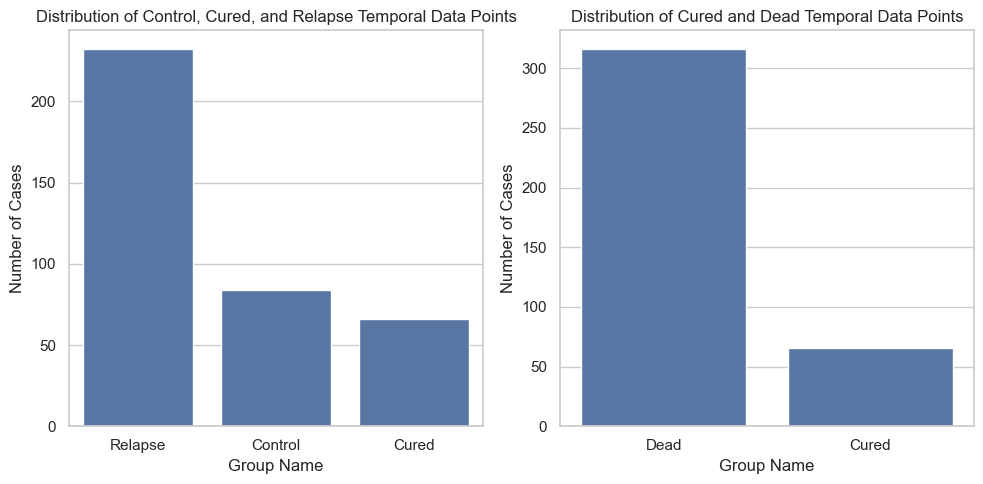

In [8]:
# Load the features from the CSV file
df_features_old = pd.read_csv(config.OLD_FEATURES_FILE_PATH)

# Set up the plot with Seaborn style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Distribution of Control, Cured, and Relapse Temporal Data Points
# Count the occurrences of each group for the first dataset
group_counts_old = df_features_old['group_name'].value_counts()

# Map the group numbers to their names
group_counts_old.index = group_counts_old.index.map({0: 'Cured', 1: 'Control', 2: 'Relapse'})

# Plot the barplot using Seaborn
sns.barplot(x=group_counts_old.index, y=group_counts_old.values, ax=ax[0])
ax[0].set_title('Distribution of Control, Cured, and Relapse Temporal Data Points')
ax[0].set_xlabel('Group Name')
ax[0].set_ylabel('Number of Cases')

# Second plot: Distribution of Cured and Dead Temporal Data Points

# Count the occurrences of each group for the second dataset
group_counts = df_features['group_name'].value_counts()

# Map the group numbers to their names
group_counts.index = group_counts.index.map({0: 'Cured', 1: 'Dead'})

# Plot the second barplot using Seaborn
sns.barplot(x=group_counts.index, y=group_counts.values, ax=ax[1])
ax[1].set_title('Distribution of Cured and Dead Temporal Data Points')
ax[1].set_xlabel('Group Name')
ax[1].set_ylabel('Number of Cases')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()


m_id
C1263    56
C1380    47
C1264    43
C1270    43
C1383    43
C1276    21
C1261    19
C1285    17
C1260    16
C1360    15
C1281    12
C1361    12
C1258     9
C1359     9
C1382     8
C1284     8
C1297     2
C1299     2
Name: count, dtype: int64


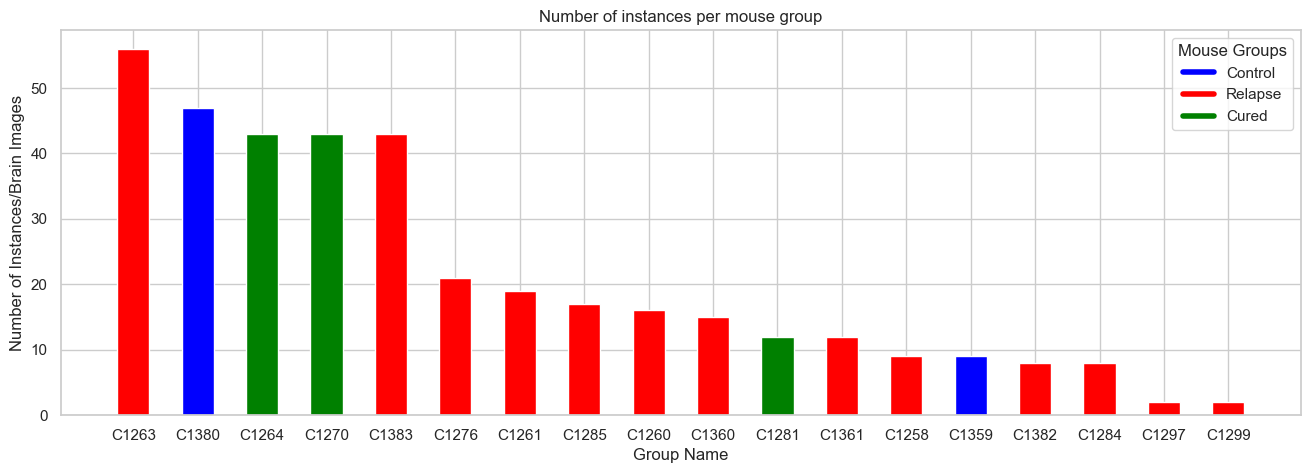

In [9]:
# Count the occurrences of each group
group_counts = df_features_old['m_id'].value_counts()
#print(group_counts)

# Convert the index to strings and add 'C' prefix to each group name
group_counts.index = 'C' + group_counts.index.astype(str)

# Mapping from group_name to categories
group_name_mapping = {0: 'Cured', 1: 'Control', 2: 'Relapse'}

# Extract the group_name column and create a mapping based on it
group_names = df_features_old['group_name'].map(group_name_mapping)

# Now create a color map based on the group_name
group_color_mapping = {'Control': 'blue', 'Relapse': 'red', 'Cured': 'green'}
colors = group_names.map(group_color_mapping)

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

print(group_counts)

# Plot the distribution of cases: Control, Relapse, Cured
bars = plt.bar(x=group_counts.index, height=group_counts.values, width=0.5, color=colors)

# Add titles and labels
plt.title('Number of instances per mouse group')
plt.xlabel('Group Name')
plt.ylabel('Number of Instances/Brain Images')

# Create a custom legend based on the group_name
legend_elements = [
    Line2D([0], [0], color='blue', lw=4, label='Control'),
    Line2D([0], [0], color='red', lw=4, label='Relapse'),
    Line2D([0], [0], color='green', lw=4, label='Cured')
]

# Add the legend to the plot
plt.legend(handles=legend_elements, title="Mouse Groups")

# Show the plot
plt.show()

C:\Users\xavie\AppData\Local\Temp\ipykernel_18120\1059070802.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[0])
C:\Users\xavie\AppData\Local\Temp\ipykernel_18120\1059070802.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[0])


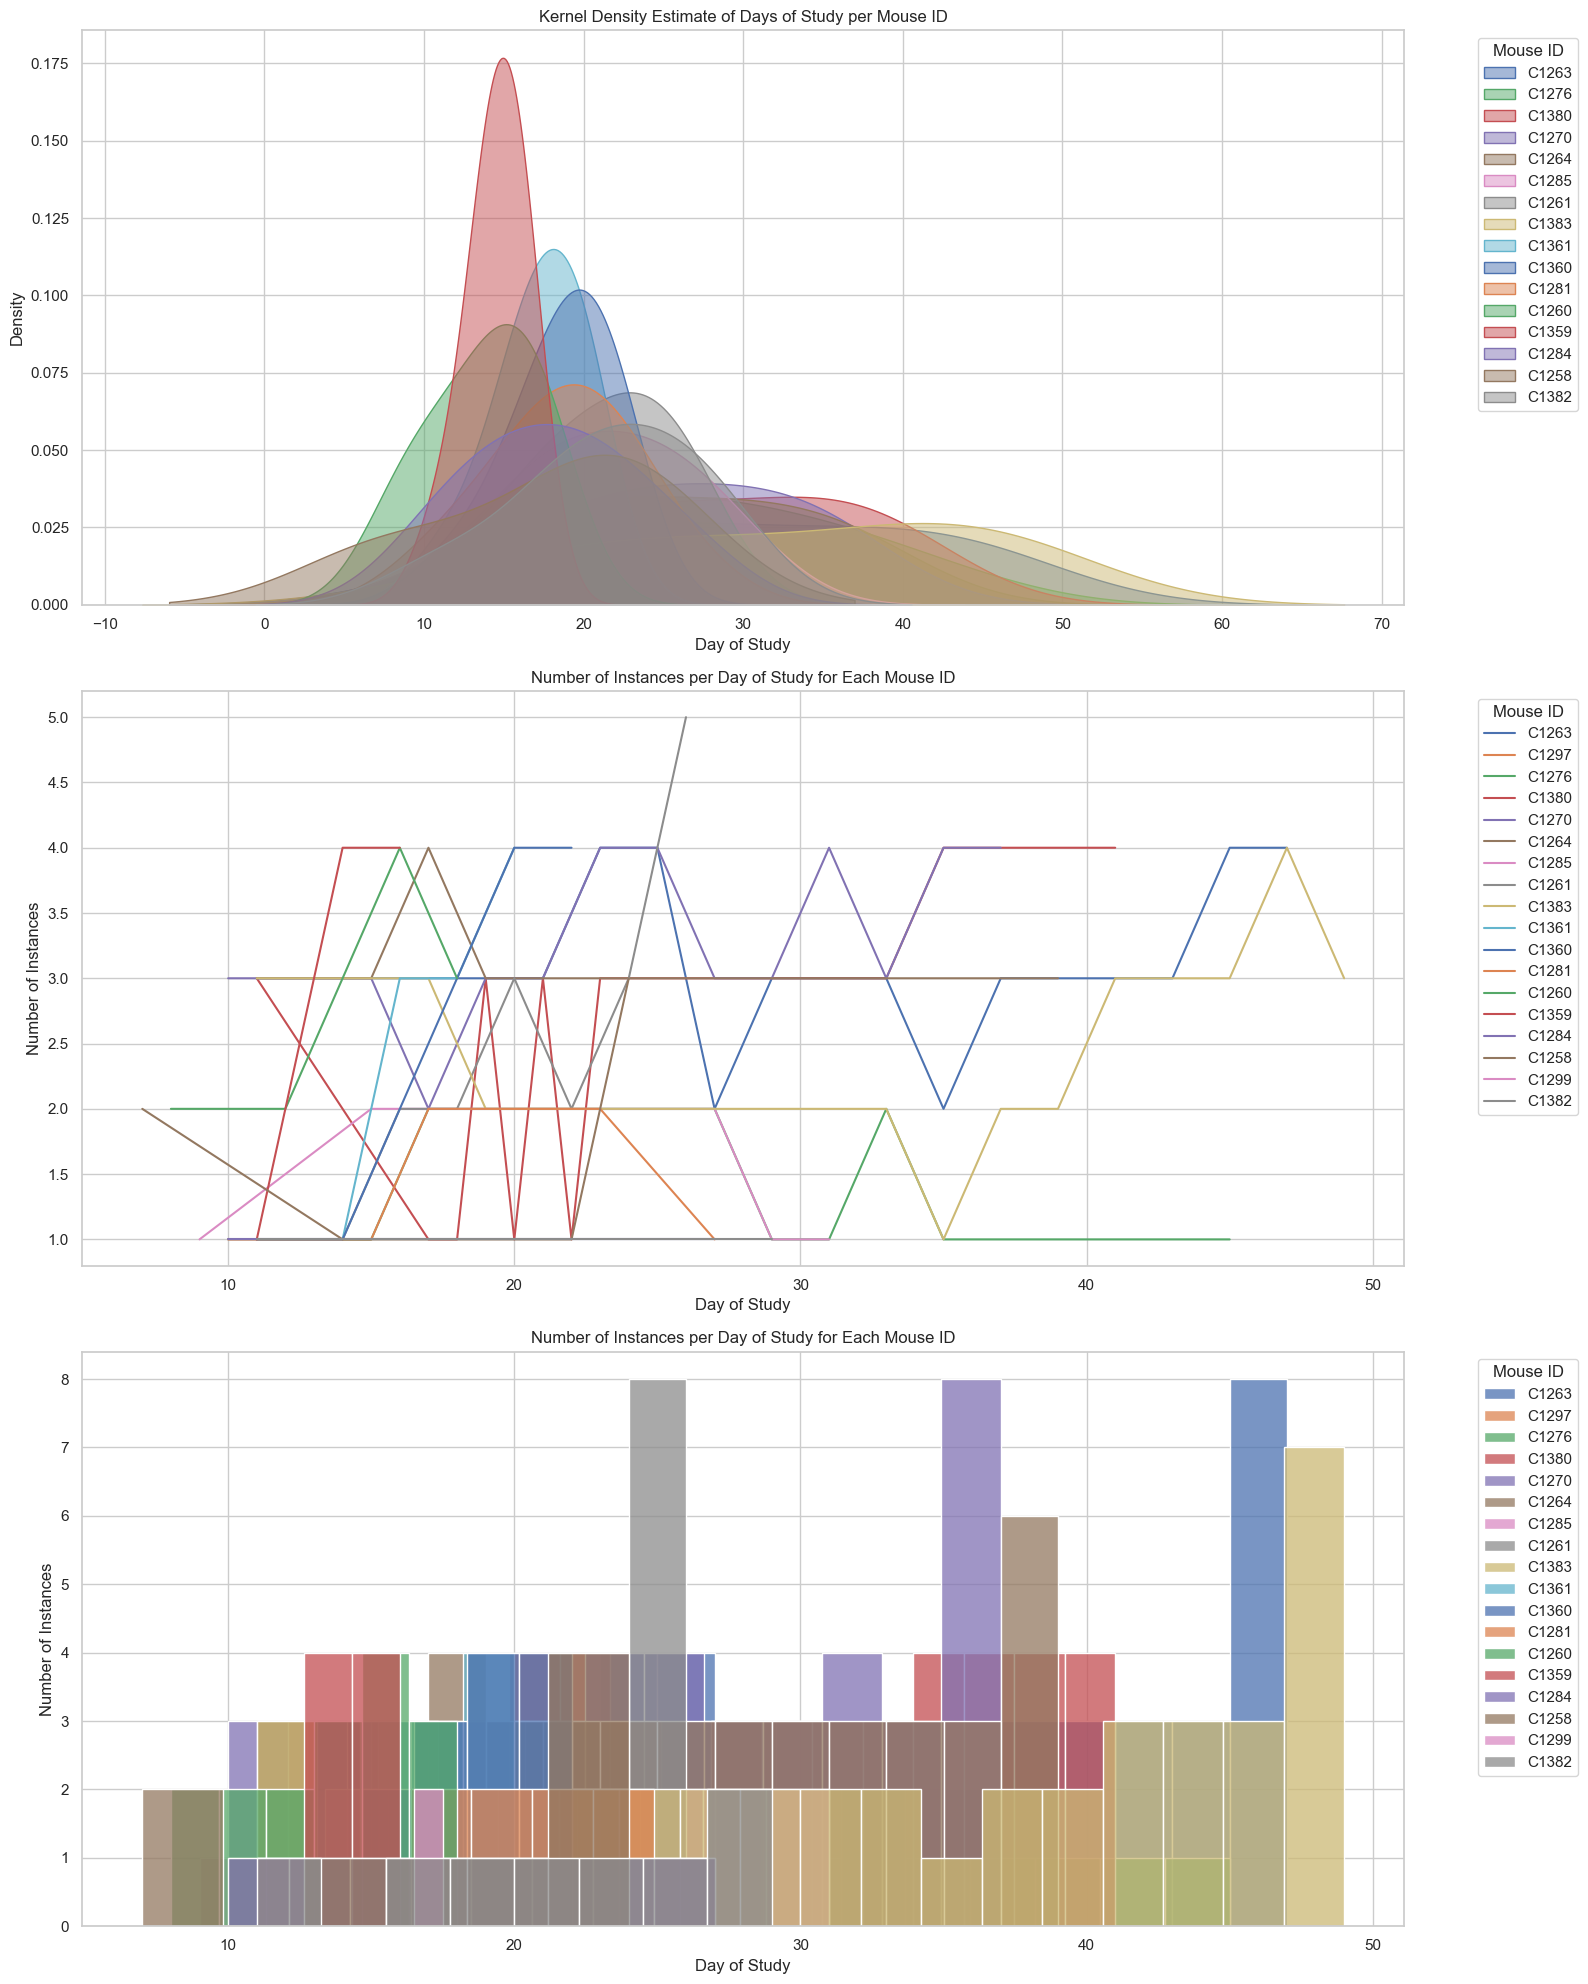

In [26]:
# Assume df_features_old is your original DataFrame
m_ids = df_features_old['m_id'].unique()  # Get unique mouse IDs

# Set up the Seaborn style
sns.set_theme(style='whitegrid')

# Create a figure with two subplots: one for KDE and one for Line plot
fig, ax = plt.subplots(3, 1, figsize=(16, 20))  # 1 row, 2 columns

# Iterate over each unique m_id
for m_id in m_ids:
    # Get the counts of days for the current mouse ID
    day_counts_per_id = df_features_old[df_features_old['m_id'] == m_id]['day_of_study'].value_counts().sort_index()

    # Check if there are any counts to avoid zero variance warning
    if day_counts_per_id.empty:
        print(f"No data for Mouse ID {m_id}. Skipping...")
        continue

    # Prepare the x-values (days) and y-values (number of instances)
    x_values = day_counts_per_id.index
    y_values = day_counts_per_id.values

    # Plot the kernel density estimate for the current mouse ID in the left subplot (ax[0])
    sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[0])

    # Plot the number of instances for the current mouse ID in the right subplot (ax[1])
    sns.lineplot(x=x_values, y=y_values, label=f'C{m_id}', ax=ax[1])

    # Plot the number of instances for the current mouse ID in the right subplot (ax[1])
    sns.histplot(x=x_values, weights=y_values, label=f'C{m_id}', ax=ax[2], bins=len(x_values))


# Set titles, labels, and legends for the KDE plot (left)
ax[0].set_title('Kernel Density Estimate of Days of Study per Mouse ID')
ax[0].set_xlabel('Day of Study')
ax[0].set_ylabel('Density')
ax[0].legend(title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set titles, labels, and legends for the Line plot (right)
ax[1].set_title('Number of Instances per Day of Study for Each Mouse ID')
ax[1].set_xlabel('Day of Study')
ax[1].set_ylabel('Number of Instances')
ax[1].legend(title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set titles, labels, and legends for the Line plot (right)
ax[2].set_title('Number of Instances per Day of Study for Each Mouse ID')
ax[2].set_xlabel('Day of Study')
ax[2].set_ylabel('Number of Instances')
ax[2].legend(title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\xavie\AppData\Local\Temp\ipykernel_18120\3434094215.py:37: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[axis_index, 0], color=color)
C:\Users\xavie\AppData\Local\Temp\ipykernel_18120\3434094215.py:37: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[axis_index, 0], color=color)


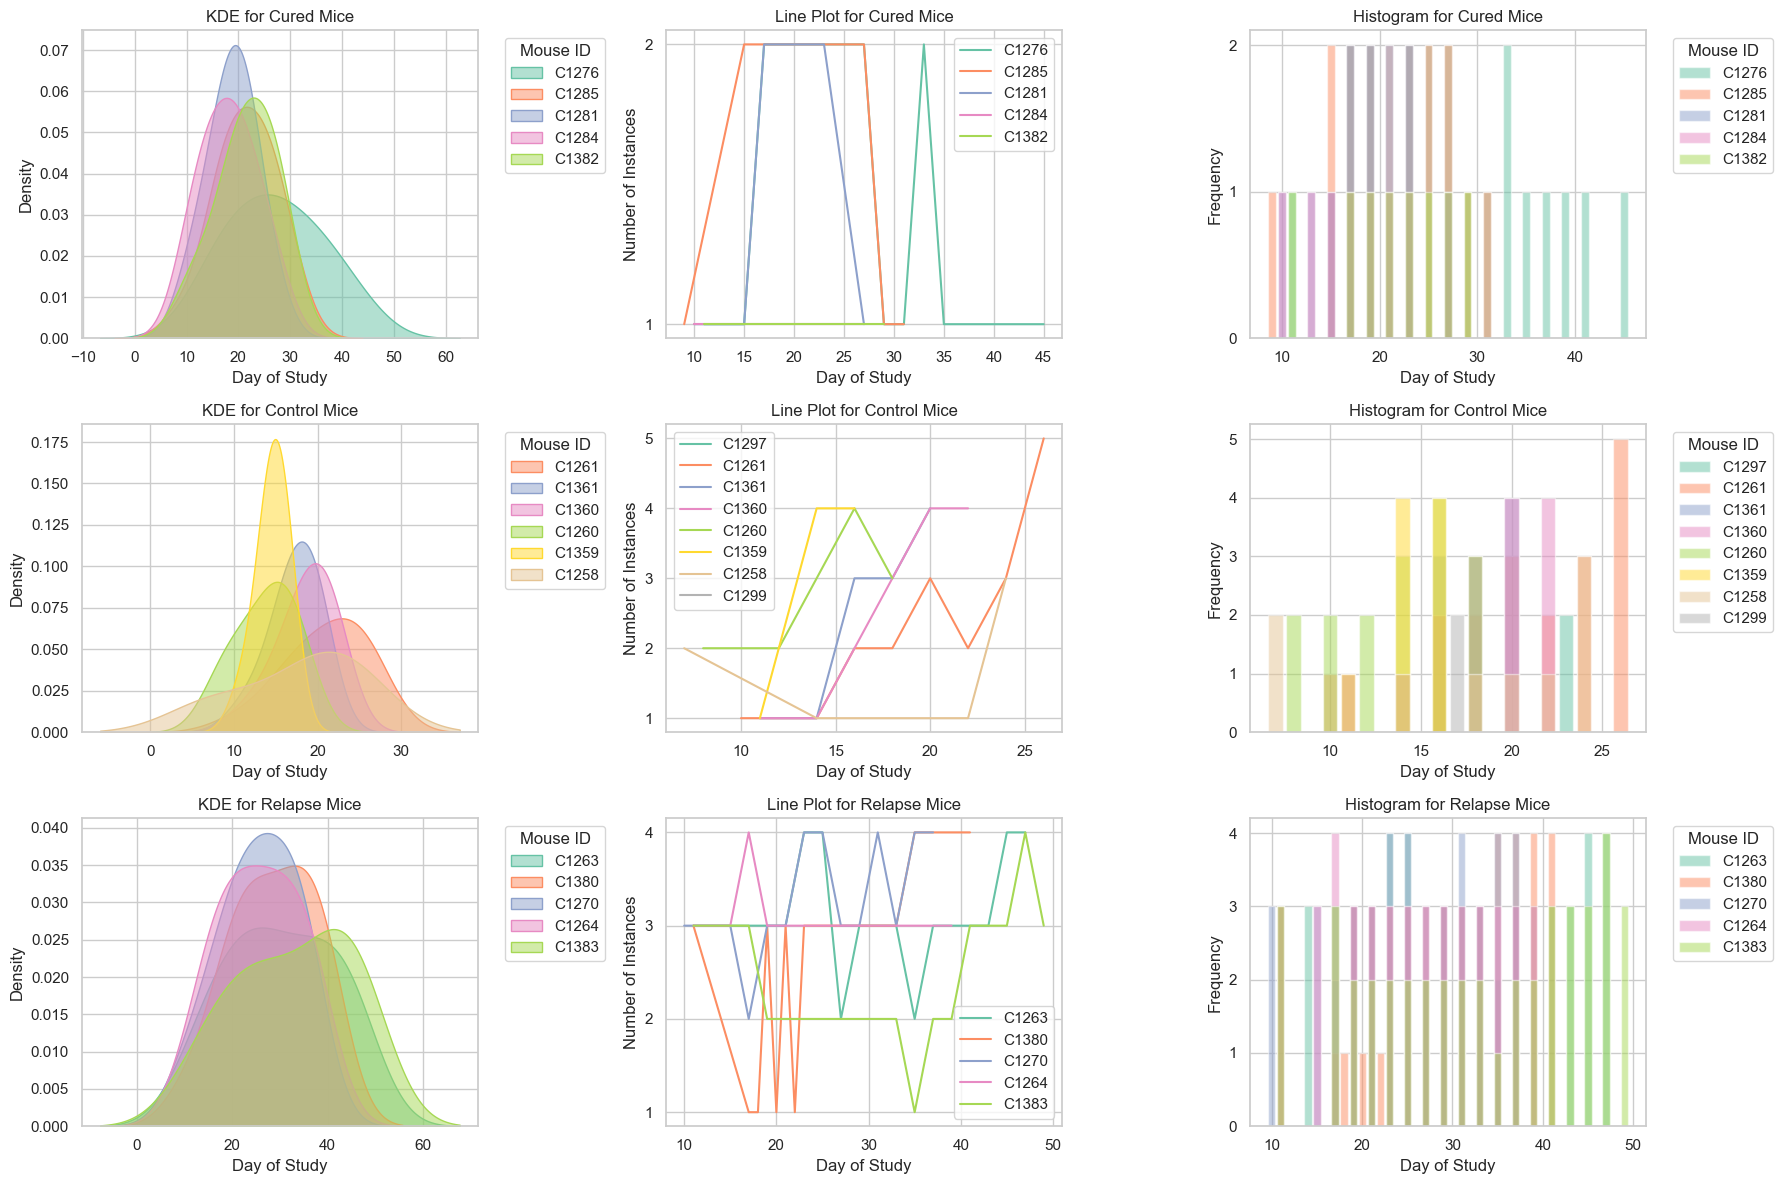

In [36]:
# Mapping from group_name to categories
group_name_mapping = {0: 'Cured', 1: 'Control', 2: 'Relapse'}

# Set up the Seaborn style
sns.set_theme(style='whitegrid')

# Create a figure with 3 rows and 3 columns: one for KDE, one for Line plot, and one for Histogram
fig, ax = plt.subplots(3, 3, figsize=(18, 12))  # 3 rows, 3 columns

# Create a color palette for the mouse IDs
palette = sns.color_palette("Set2")

# Iterate over each group: 'Cured', 'Control', 'Relapse'
for group, axis_index in zip(['Cured', 'Control', 'Relapse'], range(3)):
    
    # Filter the dataframe for the current group
    group_data = df_features_old[df_features_old['group_name'] == list(group_name_mapping.keys())[list(group_name_mapping.values()).index(group)]]

    # Iterate over each unique m_id in the current group
    for i, m_id in enumerate(group_data['m_id'].unique()):
        # Get the counts of days for the current mouse ID in the current group
        day_counts_per_id = group_data[group_data['m_id'] == m_id]['day_of_study'].value_counts().sort_index()

        # Check if there are any counts to avoid zero variance warning
        if day_counts_per_id.empty:
            print(f"No data for Mouse ID {m_id}. Skipping...")
            continue

        # Prepare the x-values (days) and y-values (number of instances)
        x_values = day_counts_per_id.index
        y_values = day_counts_per_id.values

        # Select a color for the current mouse ID
        color = palette[i % len(palette)]  # Cycle through the palette

        # Plot the kernel density estimate for the current mouse ID in the left subplot (KDE)
        sns.kdeplot(x=x_values, weights=y_values, label=f'C{m_id}', fill=True, alpha=0.5, ax=ax[axis_index, 0], color=color)

        # Plot the number of instances for the current mouse ID in the middle subplot (Line plot)
        sns.lineplot(x=x_values, y=y_values, label=f'C{m_id}', ax=ax[axis_index, 1], color=color)

        # Plot the histogram for the current mouse ID in the right subplot (Histogram)
        # Create a DataFrame to use for the histogram
        histogram_data = pd.DataFrame({
            'day_of_study': day_counts_per_id.index,
            'counts': day_counts_per_id.values
        })

        # Use barplot for histogram representation
        ax[axis_index, 2].bar(histogram_data['day_of_study'], histogram_data['counts'], label=f'C{m_id}', color=color, alpha=0.5)

    # Set titles for each subplot
    ax[axis_index, 0].set_title(f'KDE for {group} Mice')
    ax[axis_index, 1].set_title(f'Line Plot for {group} Mice')
    ax[axis_index, 2].set_title(f'Histogram for {group} Mice')

    # Add legends for KDE and Histogram subplots
    ax[axis_index, 0].legend(title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax[axis_index, 2].legend(title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set general labels for the axes
for i in range(3):
    ax[i, 0].set_xlabel('Day of Study')
    ax[i, 0].set_ylabel('Density')
    ax[i, 1].set_xlabel('Day of Study')
    ax[i, 1].set_ylabel('Number of Instances')
    ax[i, 2].set_xlabel('Day of Study')
    ax[i, 2].set_ylabel('Frequency')

    # Leave only integers on y axis for the lineplot and histogram
    ax[i, 1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax[i, 2].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Adjust layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()
